In [17]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import os
import csv
import pandas as pd


import scipy.stats
from sklearn.linear_model import LinearRegression

import torch
from networks_update import Encoder, Decoder
import math
import random
import glob

In [2]:
# HELPERS

# Ensures consistent colouring of values even with missing labels
from matplotlib.colors import ListedColormap, BoundaryNorm

# Get the 20 distinct colors from tab20
base_colors = plt.cm.get_cmap('tab20').colors  # tuple of 20 RGBA colors

# Repeat them to cover 300 labels
n_labels = 271
repeated_colors = np.tile(base_colors, (n_labels // 20 + 1, 1))[:n_labels]

# Create a ListedColormap
cmap = ListedColormap(repeated_colors)

def plot_seg(img_arr, slice_idx, size, title):
    plt.figure(figsize=(size, size))
    #plt.imshow(np.ma.masked_where(img_arr[slice_idx] == 0, img_arr[slice_idx]), cmap=cmap, norm=norm, alpha=1.0, interpolation='nearest')
    plt.imshow(np.ma.masked_where(img_arr[slice_idx] == 0, img_arr[slice_idx]), cmap=cmap, vmin=0, vmax=270, alpha=1.0, interpolation='nearest')
    plt.title(title)
    plt.show()


# 3. Plot the volume rato distributions (of common + maybe not commom stucts)

def get_vol_ratio(img_arr):
    vol_ratios = []
    total_count = np.sum(img_arr != 0)

    for i in range(251, 270 + 1):
        vol_ratios.append(0 if total_count == 0 else np.sum(img_arr == i) / total_count)

    return vol_ratios

def compute_common_vol_ratios(folder_path):
    folder_list = os.listdir(folder_path)
    folder_list.sort()
    #folder_list.pop(0)
    folder_list.pop(24)

    vol_ratios = []
    for file_name in folder_list:
        img = sitk.ReadImage(folder_path + file_name)
        img_arr = sitk.GetArrayFromImage(img)
        vol_ratios.append(get_vol_ratio(img_arr))

    vol_ratios = np.vstack(vol_ratios)

    return vol_ratios

img_idx =0
def plot_vol_ratios(real_vol_ratios, synth_vol_ratios, struct_names, plot_cor=True, img_idx=img_idx):
    
    common_struct_colors = repeated_colors[251:]
    bins = 50

    fig2, axs2 = plt.subplots(2, 10, figsize=(35, 6))

    for plot_index in range(2):  # Two sets: 0–9 and 10–19
        fig, axs = plt.subplots(2, 10, figsize=(30, 5))
        
        for i in range(10):
            struct_i = plot_index * 10 + i
            if struct_i >= len(struct_names):
                break
            
            color = common_struct_colors[struct_i]

            real_data = real_vol_ratios[:, struct_i]
            synth_data = synth_vol_ratios[:, struct_i]
            combined_min = min(np.min(real_data), np.min(synth_data))
            combined_max = max(np.max(real_data), np.max(synth_data))
            if combined_min == combined_max:
                continue
                
            if plot_cor:
                # analyze matter preservation
                r, p = scipy.stats.pearsonr(real_data, synth_data)

                # # try scaling first???
                # from sklearn.preprocessing import StandardScaler

                # scaler = StandardScaler()
                # arr1_scaled = scaler.fit_transform(real_data.reshape(-1, 1)).flatten()
                # arr2_scaled = scaler.fit_transform(synth_data.reshape(-1, 1)).flatten()

                # r, p = scipy.stats.pearsonr(arr1_scaled, arr2_scaled)

                real_reshape = np.array(real_data).reshape(-1, 1)
                synth_reshape = np.array(synth_data).reshape(-1, 1)
                model = LinearRegression().fit(real_reshape, synth_reshape)

                # Predict y values for the regressed line
                y_pred = model.predict(real_reshape)

                axs2[plot_index, i].scatter(real_data, synth_data, color=color)
                axs2[plot_index, i].plot(real_data, y_pred, color="black")
                axs2[plot_index, i].set_xlim(combined_min*0.90, combined_max*1.03)
                axs2[plot_index, i].set_ylim(combined_min*0.90, combined_max*1.03)
                axs2[plot_index, i].set_title(struct_names[struct_i] + "(pearsons r=" + str(round(r, 2)) + ")", fontsize=8)

                # plot target idx in black
                axs2[plot_index, i].scatter(real_data[img_idx], synth_data[img_idx], color='black', s=100)


            bin_edges = np.linspace(combined_min, combined_max, bins + 1)
        
            # Real
            axs[0, i].set_xlim(combined_min*0.95, combined_max*1.05)
            axs[0, i].hist(real_vol_ratios[:, struct_i], bins=bin_edges, color=color)
            axs[0, i].set_title(struct_names[struct_i], fontsize=8)
            axs[0, i].tick_params(labelsize=6)

            # Synthetic
            axs[1, i].set_xlim(combined_min*0.95, combined_max*1.05)
            axs[1, i].hist(synth_vol_ratios[:, struct_i], bins=bin_edges, color=color)
            axs[1, i].tick_params(labelsize=6)

        axs[0, 0].set_ylabel("Real vol ratios", fontsize=10)
        axs[1, 0].set_ylabel("Recon vol ratios", fontsize=10)

        fig.tight_layout()
        fig.show()

    fig2.tight_layout()
    fig2.show()


struct_names = ['lateral ventricle', 'basal forebrain', 'hippocampus', 'amygdala', 'fourth ventricle', 'thalamus', 'third ventricle', 'arbor vita of cerebellum', 'nucleus accumbens', 'globus pallidus']
struct_names = [[struct_name + " R", struct_name + " L"] for struct_name in struct_names]
struct_names = [n for pair in struct_names for n in pair]

import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt

def compute_voxelwise_entropy(imgs, num_classes=271):
    """
    imgs: list of 3D numpy arrays of segmentation masks
    returns: 3D array of voxelwise entropy
    """
    imgs = np.stack(imgs, axis=0).astype(np.int64)  # cast to int for bincount
    N, X, Y, Z = imgs.shape
    voxel_entropy = np.zeros((X, Y, Z))

    for x in range(X):
        for y in range(Y):
            for z in range(Z):
                vals = imgs[:, x, y, z]
                counts = np.bincount(vals, minlength=num_classes)
                if counts.sum() == 0:
                    voxel_entropy[x, y, z] = 0.0
                else:
                    p = counts / counts.sum()
                    voxel_entropy[x, y, z] = -np.sum(p * np.log(p + 1e-12)) / np.log(num_classes)  # normalized entropy

    return voxel_entropy


# ---- Example plot (central slice) ----
def plot_entropy_heatmap(voxel_entropy, axis=0, slice_idx=None, title=""):
    if slice_idx is None:
        slice_idx = voxel_entropy.shape[axis] // 2
    if axis == 0:
        img = voxel_entropy[slice_idx, :, :]
    elif axis == 1:
        img = voxel_entropy[:, slice_idx, :]
    else:
        img = voxel_entropy[:, :, slice_idx]
    plt.figure(figsize=(3,3))
    plt.imshow(img, cmap="jet", origin="lower", vmax=0.3)
    plt.colorbar(label="Normalized Entropy (0–1)")
    plt.title(title)
    plt.show()


/tmp/ipykernel_740560/3992057542.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base_colors = plt.cm.get_cmap('tab20').colors  # tuple of 20 RGBA colors


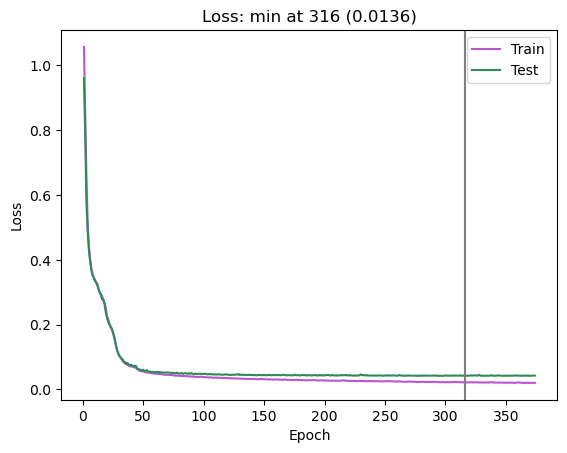

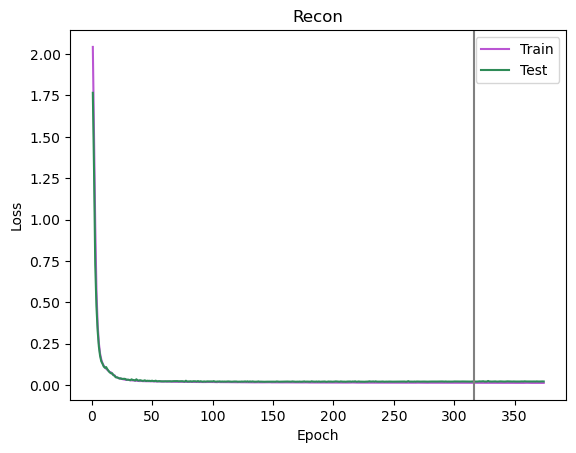

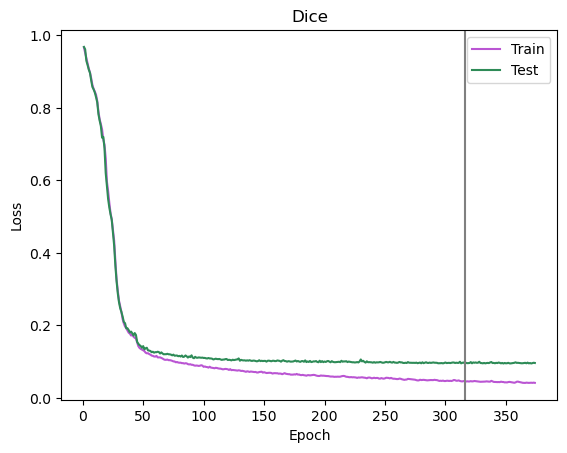

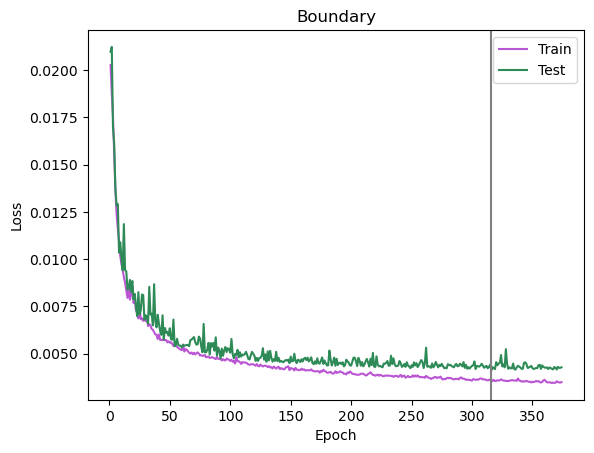

In [25]:
# 1. Plot loss
loss = pd.read_csv("../VQ-VAE/save_trains/UNET/train_mouse_bc_16_d_3/loss_log.csv")

min_test = loss.iloc[:, 0][np.argmin(loss.iloc[:, 9])]

plt.figure()
plt.plot(loss.iloc[:, 0], loss.iloc[:, 1], color="mediumorchid")
plt.plot(loss.iloc[:, 0], loss.iloc[:, 6], color="seagreen")
#plt.plot(test_loss.iloc[:, 0], test_loss.iloc[:, 1], color="seagreen") # for human when saving was off
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Test"])
plt.axvline(min_test, color="grey")
plt.title("Loss: min at " + str(min_test) + " (" + str(round(np.min(loss.iloc[:, 2]), 4)) +")")
plt.show()

plt.figure()
plt.plot(loss.iloc[:, 0], loss.iloc[:, 2], color="mediumorchid")
plt.plot(loss.iloc[:, 0], loss.iloc[:, 7], color="seagreen")
#plt.plot(test_loss.iloc[:, 0], test_loss.iloc[:, 1], color="seagreen") # for human when saving was off
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Test"])
plt.axvline(min_test, color="grey")
plt.title("Recon")
plt.show()

plt.figure()
plt.plot(loss.iloc[:, 0], loss.iloc[:, 3], color="mediumorchid")
plt.plot(loss.iloc[:, 0], loss.iloc[:, 8], color="seagreen")
#plt.plot(test_loss.iloc[:, 0], test_loss.iloc[:, 1], color="seagreen") # for human when saving was off
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Test"])
plt.axvline(min_test, color="grey")
plt.title("Dice")
plt.show()

plt.figure()
plt.plot(loss.iloc[:, 0], loss.iloc[:, 4], color="mediumorchid")
plt.plot(loss.iloc[:, 0], loss.iloc[:, 9], color="seagreen")
#plt.plot(test_loss.iloc[:, 0], test_loss.iloc[:, 1], color="seagreen") # for human when saving was off
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Test"])
plt.axvline(min_test, color="grey")
plt.title("Boundary")
plt.show()

## FOR COMB

In [6]:
base_colors = list(plt.cm.get_cmap('tab20').colors)
set_2 = list(plt.cm.get_cmap('Set2').colors)
base_colors.pop(14)
base_colors.pop(14)

n_labels = 20
base_colors = base_colors + set_2[:2]

get_greys = plt.cm.get_cmap('tab20c').colors

def rotate(l, n):
    return l[n:] + l[:n]

base_colors = rotate(base_colors, 11)

base_colors.insert(0, (1.0, 1.0, 1.0))
base_colors.insert(0, get_greys[17])
base_colors.insert(0, get_greys[16])
base_colors.insert(0, (1.0, 1.0, 1.0))


cmap = ListedColormap(base_colors)


# Save vol ratios plot
def get_vol_ratio(img_arr):
    vol_ratios = []
    total_count = np.sum(img_arr != 0)

    for i in range(0, 24):
        vol_ratios.append(0 if total_count == 0 else np.sum(img_arr == i) / total_count)

    return vol_ratios

def compute_common_vol_ratios(folder_path):
    folder_list = os.listdir(folder_path)
    folder_list.sort()

    vol_ratios = []
    for file_name in folder_list:
        img = sitk.ReadImage(folder_path + file_name)
        img_arr = sitk.GetArrayFromImage(img)
        vol_ratios.append(get_vol_ratio(img_arr))

    vol_ratios = np.vstack(vol_ratios)

    return vol_ratios


def plot_vol_ratios(real_vol_ratios, synth_vol_ratios, struct_names, plot_scatter=True, plot_hist=True):
    common_struct_colors = base_colors

    fig2, axs2 = plt.subplots(2, 13, figsize=(40, 6))
    bins = 50

    for plot_index in range(2):  # Two sets: 0–9 and 10–19
        fig, axs = plt.subplots(2, 13, figsize=(30, 5))
        
        for i in range(13):
            struct_i = plot_index * 13 + i
            if struct_i + 1 >= len(common_struct_colors):
                break
            
            color = common_struct_colors[struct_i + 1]

            real_data = real_vol_ratios[:, struct_i + 1]
            synth_data = synth_vol_ratios[:, struct_i + 1]
            combined_min = min(np.min(real_data), np.min(synth_data))
            combined_max = max(np.max(real_data), np.max(synth_data))
            if combined_min == combined_max:
                continue
            
            if plot_scatter:
                # analyze matter preservation
                r, p = scipy.stats.pearsonr(real_data, synth_data)

                real_reshape = np.array(real_data).reshape(-1, 1)
                synth_reshape = np.array(synth_data).reshape(-1, 1)
                model = LinearRegression().fit(real_reshape, synth_reshape)

                # Predict y values for the regressed line
                y_pred = model.predict(real_reshape)

                axs2[plot_index, i].scatter(real_data, synth_data, color=color)
                axs2[plot_index, i].plot(real_data, y_pred, color="black")
                axs2[plot_index, i].set_xlim(combined_min*0.90, combined_max*1.03)
                axs2[plot_index, i].set_ylim(combined_min*0.90, combined_max*1.03)
                axs2[plot_index, i].set_title(struct_names[struct_i] + "(pearsons r=" + str(round(r, 2)) + ")", fontsize=8)


            bin_edges = np.linspace(combined_min, combined_max, bins + 1)
        
            # Real
            axs[0, i].set_xlim(combined_min*0.9, combined_max*1.10)
            axs[0, i].hist(real_vol_ratios[:, struct_i + 1], bins=bin_edges, color=color)
            axs[0, i].set_title(struct_names[struct_i], fontsize=8)
            axs[0, i].tick_params(labelsize=6)

            # Synthetic
            axs[1, i].set_xlim(combined_min*0.9, combined_max*1.10)
            axs[1, i].hist(synth_vol_ratios[:, struct_i + 1], bins=bin_edges, color=color)
            axs[1, i].tick_params(labelsize=6)

        axs[0, 0].set_ylabel("Real vol ratios", fontsize=10)
        axs[1, 0].set_ylabel("Recon vol ratios", fontsize=10)


    if plot_scatter:
        fig2.tight_layout()
        fig2.show()

    if plot_hist:
        fig.tight_layout()
        fig.show()

struct_names = ['lateral ventricle', 'basal forebrain', 'hippocampus', 'amygdala', 'fourth ventricle', 'thalamus', 'third ventricle', 'arbor vita of cerebellum', 'nucleus accumbens', 'globus pallidus']
struct_names = [[struct_name + " R", struct_name + " L"] for struct_name in struct_names]
struct_names = [n for pair in struct_names for n in pair]
struct_names = ['GM', 'WM', 'CSF'] + struct_names

/tmp/ipykernel_27935/4067598822.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base_colors = list(plt.cm.get_cmap('tab20').colors)
/tmp/ipykernel_27935/4067598822.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  set_2 = list(plt.cm.get_cmap('Set2').colors)
/tmp/ipykernel_27935/4067598822.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  get_greys = plt.cm.get_cmap('tab20c').colors


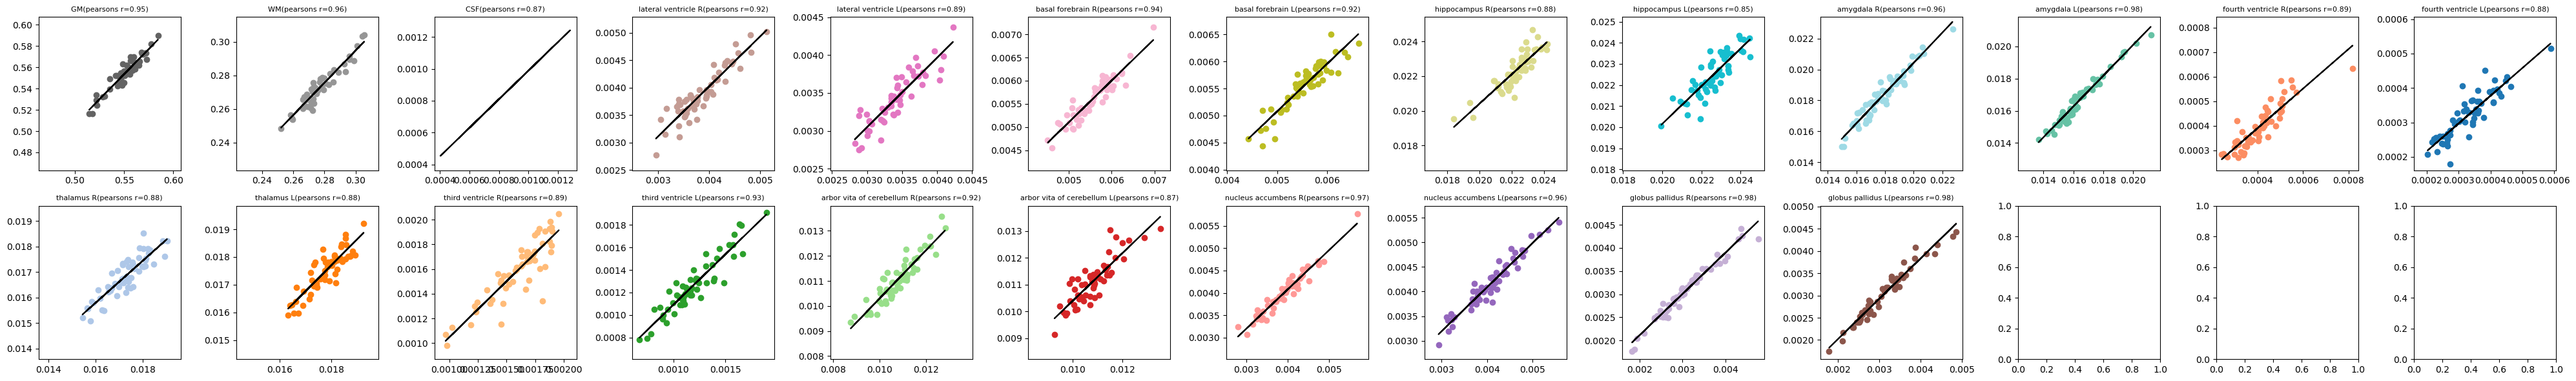

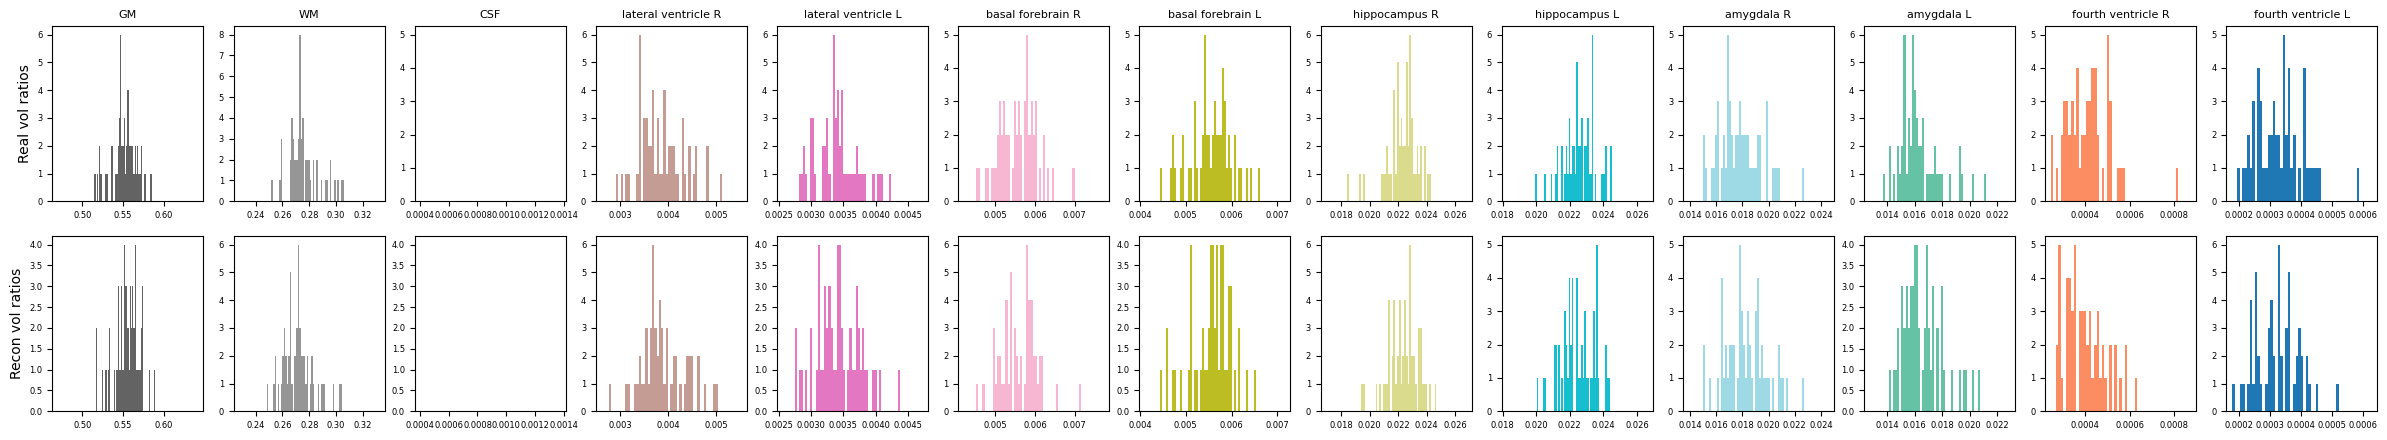

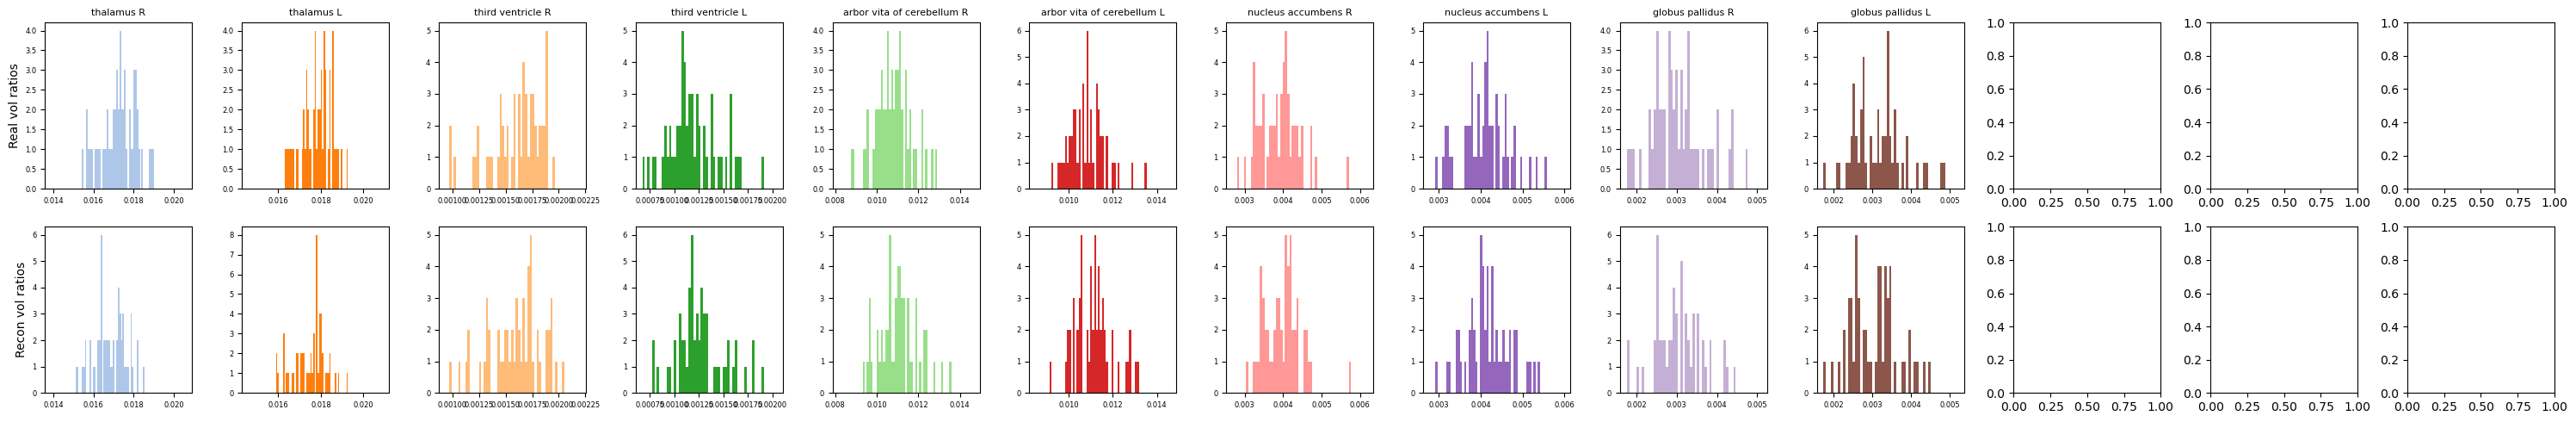

In [9]:
real_imgs_path = "./datasets/comb/mouse_test/"
recon_imgs_path = "../VQ-VAE/save_trains/UNET/train_mouse_film_vae_kl_anneal/recon_images_best/"


recon_vol_ratios = compute_common_vol_ratios(recon_imgs_path)
real_vol_ratios = compute_common_vol_ratios(real_imgs_path)

plot_vol_ratios(real_vol_ratios, recon_vol_ratios, struct_names, plot_scatter=True)


### FOR ANNAT

Mean accuracy: 0.9457


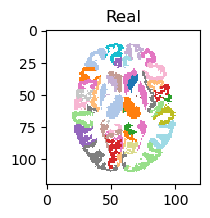

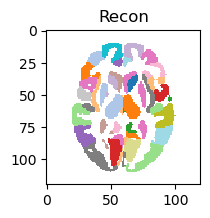

Missing common labels: []


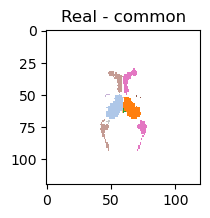

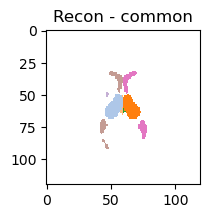

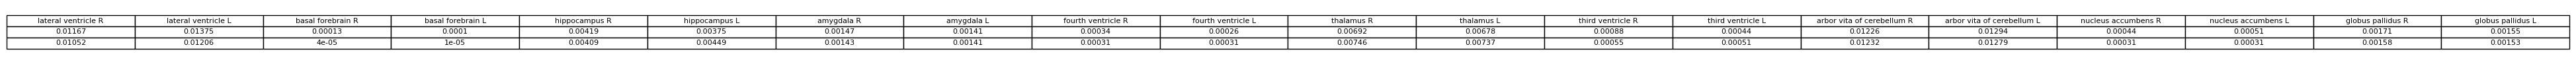

Mean accuracy: 0.9494


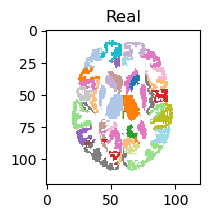

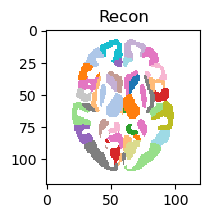

Missing common labels: []


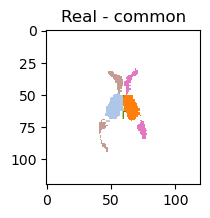

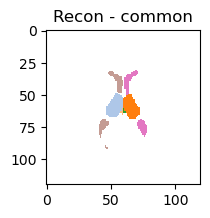

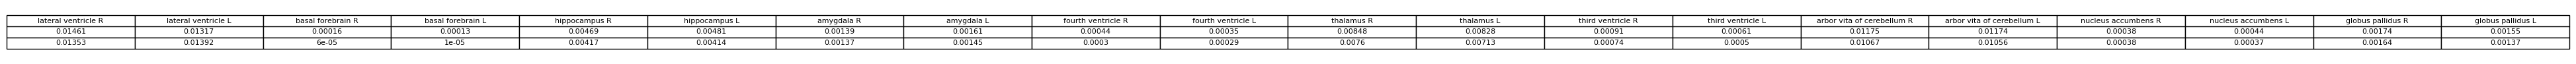

Mean accuracy: 0.9464


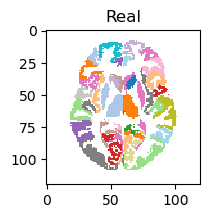

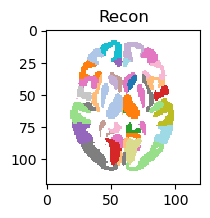

Missing common labels: []


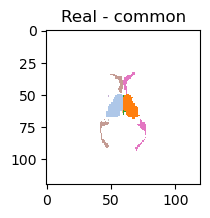

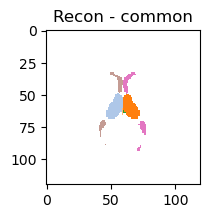

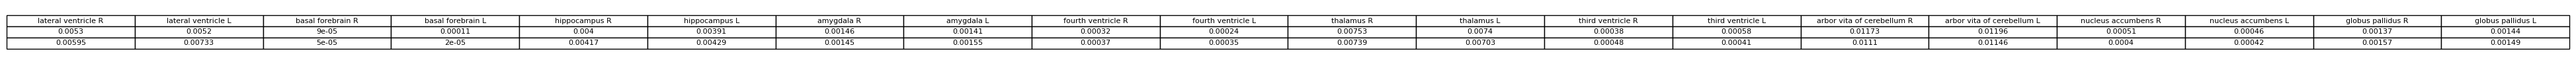

Mean accuracy: 0.9454


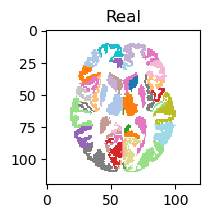

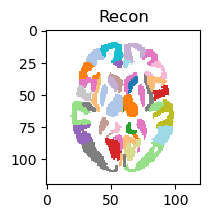

Missing common labels: []


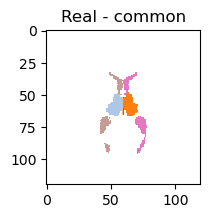

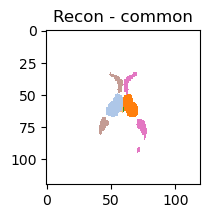

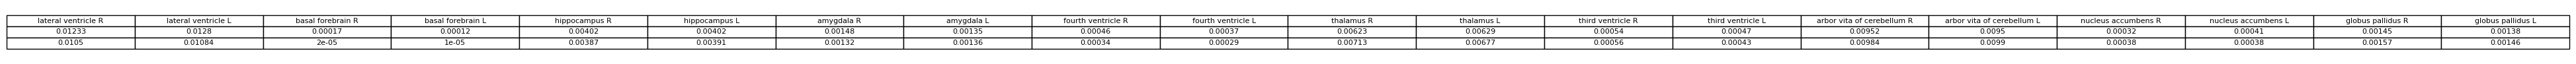

Mean accuracy: 0.9463


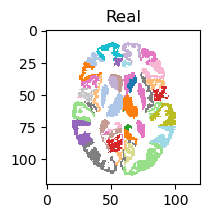

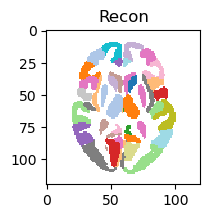

Missing common labels: [253.]


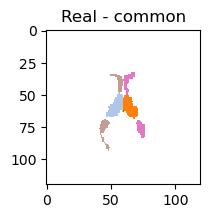

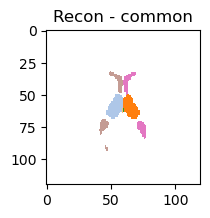

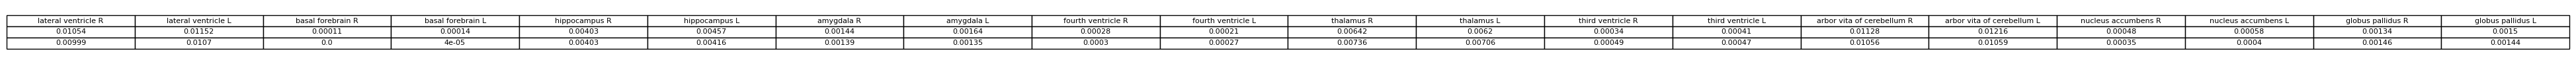

In [5]:
# 1. Print real vs synth

real_imgs_path = "./datasets/3d_anat_align/human_test/"
recon_imgs_path = "./VAE_train/3d_anat/arc_human_train_7/recon_images_best/"

# real_imgs_path = "./datasets/anat/mouse_test/"
# recon_imgs_path = "./save_anat_e_d/mouse_train_2/recon_images_epoch_125/"

real_imgs_files = os.listdir(real_imgs_path)
real_imgs_files.sort()
recon_imgs_files = os.listdir(recon_imgs_path)
recon_imgs_files.sort()

# real_imgs_files.pop(43)
# real_imgs_files.pop(34)

# recon_imgs_files.pop(43)
# recon_imgs_files.pop(34)

img_idxs = np.arange(0, 5)

for img_idx in img_idxs[:5]:
    real_img = sitk.GetArrayFromImage(sitk.ReadImage(real_imgs_path + real_imgs_files[img_idx]))
    recon_img = sitk.GetArrayFromImage(sitk.ReadImage(recon_imgs_path + recon_imgs_files[img_idx]))

    # Plot comparison of common strut volumes
    real_vols = np.round(get_vol_ratio(real_img), 5)
    recon_vols = np.round(get_vol_ratio(recon_img), 5)


    # real_img = sitk.GetArrayFromImage(sitk.ReadImage("./datasets/anat/mouse_test/18032_05_RARE.nii"))
    # recon_img = sitk.GetArrayFromImage(sitk.ReadImage("./save_anat_e_d/mouse_train_1/test_images/recon_18032_05_RARE_epoch_330.nii"))

    acc = np.mean(real_img == recon_img)
    print("Mean accuracy:", str(np.round(acc, 4)))

    slice_idx = 64
    size = 2

    #print("Missing labels:", np.setdiff1d(np.unique(real_img), np.unique(recon_img)))
    title = "Real"
    plot_seg(real_img, slice_idx, size, title)

    title = "Recon"
    plot_seg(recon_img, slice_idx, size, title)

    # ONLY PLOT COMMON STUCTS
    real_common = real_img
    real_common[real_img < 251] = 0
    recon_common = recon_img
    recon_common[recon_img < 251] = 0

    print("Missing common labels:", np.setdiff1d(np.unique(real_common), np.unique(recon_common)))
    title = "Real - common"
    plot_seg(real_common, slice_idx, size, title)

    title = "Recon - common"
    plot_seg(recon_common, slice_idx, size, title)

    fig, ax = plt.subplots(figsize=(50, 1))
    ax.axis('off')  # hide plot frame


    # Add table
    table = ax.table(
        cellText=[real_vols, recon_vols],
        colLabels=struct_names,
        loc='center',
        cellLoc='center'
    )

    plt.show()

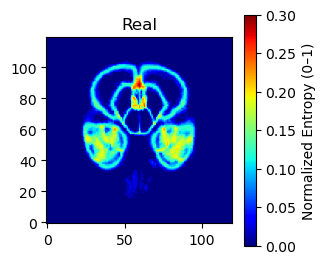

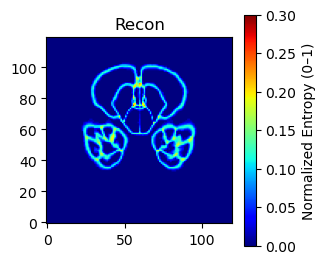

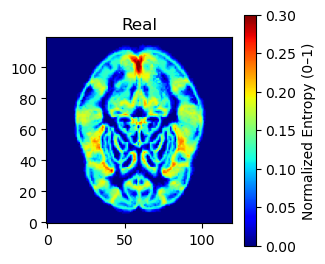

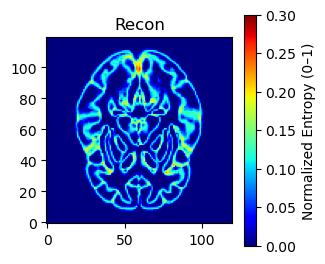

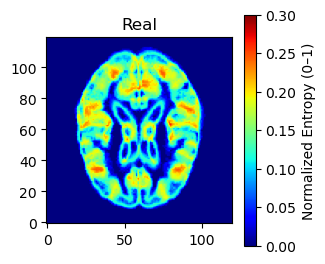

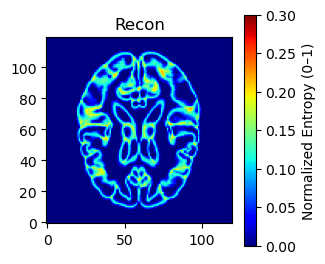

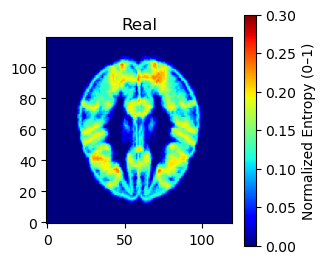

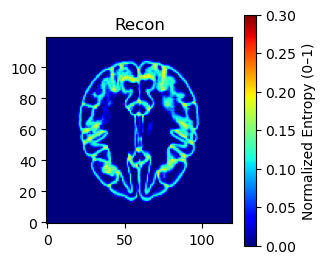

In [6]:
# plot categorical voxelwise variance in 
# 4. Calculate variance of train, test, and recon datasets
human_real_paths = glob.glob("./datasets/3d_anat_align/human_test/*")

real_imgs = []
for img_path in human_real_paths:
    img_arr = sitk.GetArrayFromImage(sitk.ReadImage(img_path))
    real_imgs.append(img_arr)

human_recon_paths = glob.glob("./VAE_train/3d_anat/arc_human_train_7/recon_images_best/*")
#human_recon_paths = glob.glob("../VQ-VAE/save_trains/train_human_VQ-VAE/recon_images/*")

recon_imgs = []
for img_path in human_recon_paths:
    img_arr = sitk.GetArrayFromImage(sitk.ReadImage(img_path))
    recon_imgs.append(img_arr)

real_voxel_variance = compute_voxelwise_entropy(real_imgs)
recon_voxel_variance = compute_voxelwise_entropy(recon_imgs)


slices = [40, 60, 70, 80]

for slice_idx in slices:
    plot_entropy_heatmap(real_voxel_variance, 0, slice_idx, "Real")
    plot_entropy_heatmap(recon_voxel_variance, 0, slice_idx, "Recon")


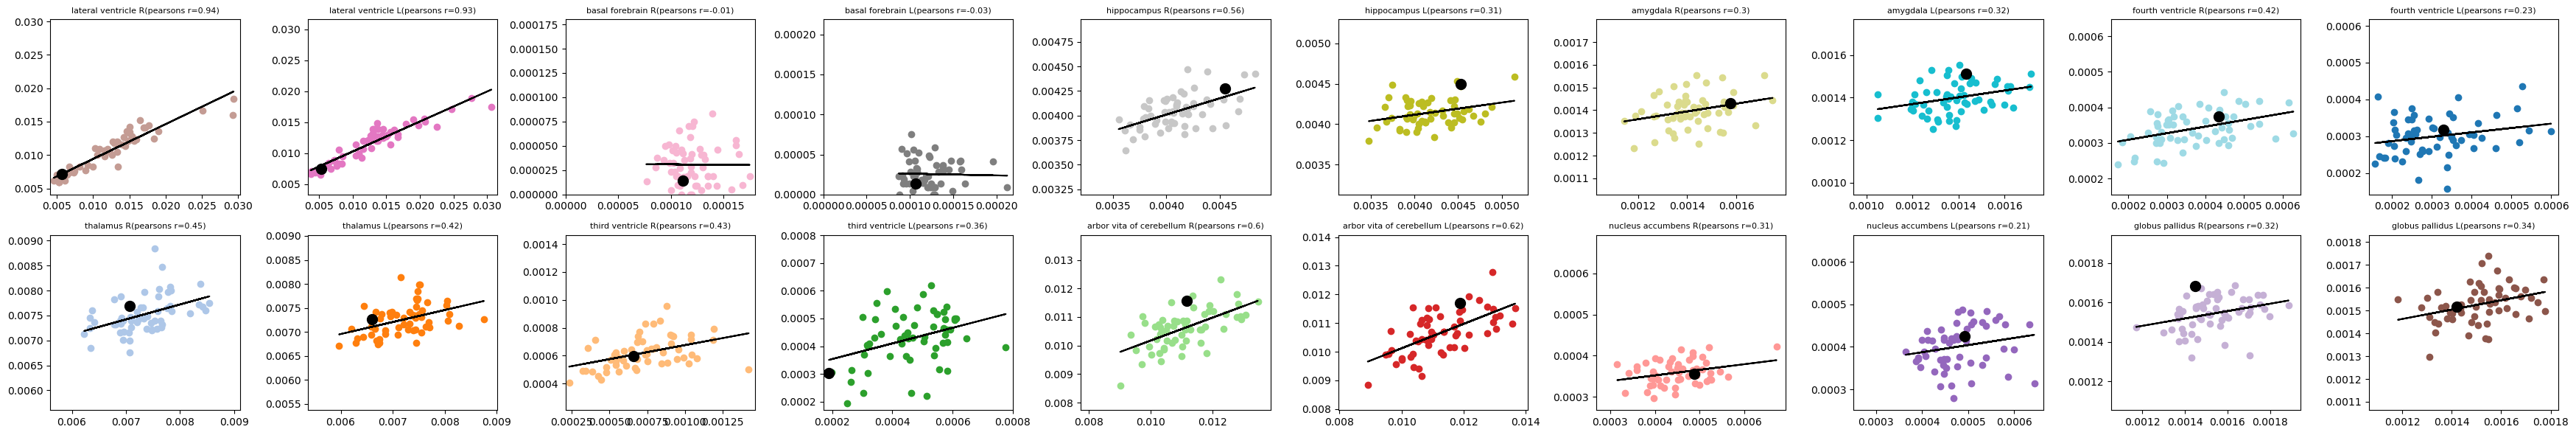

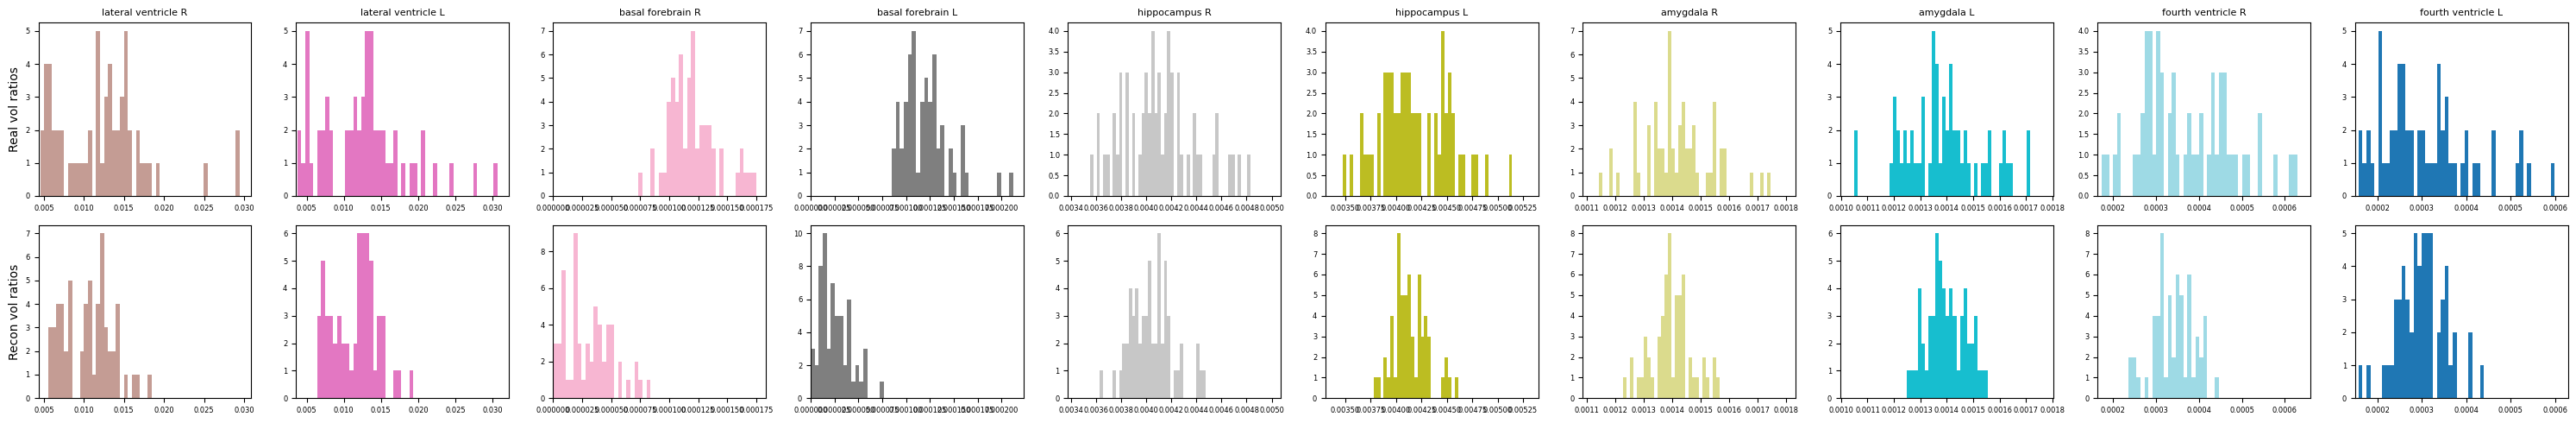

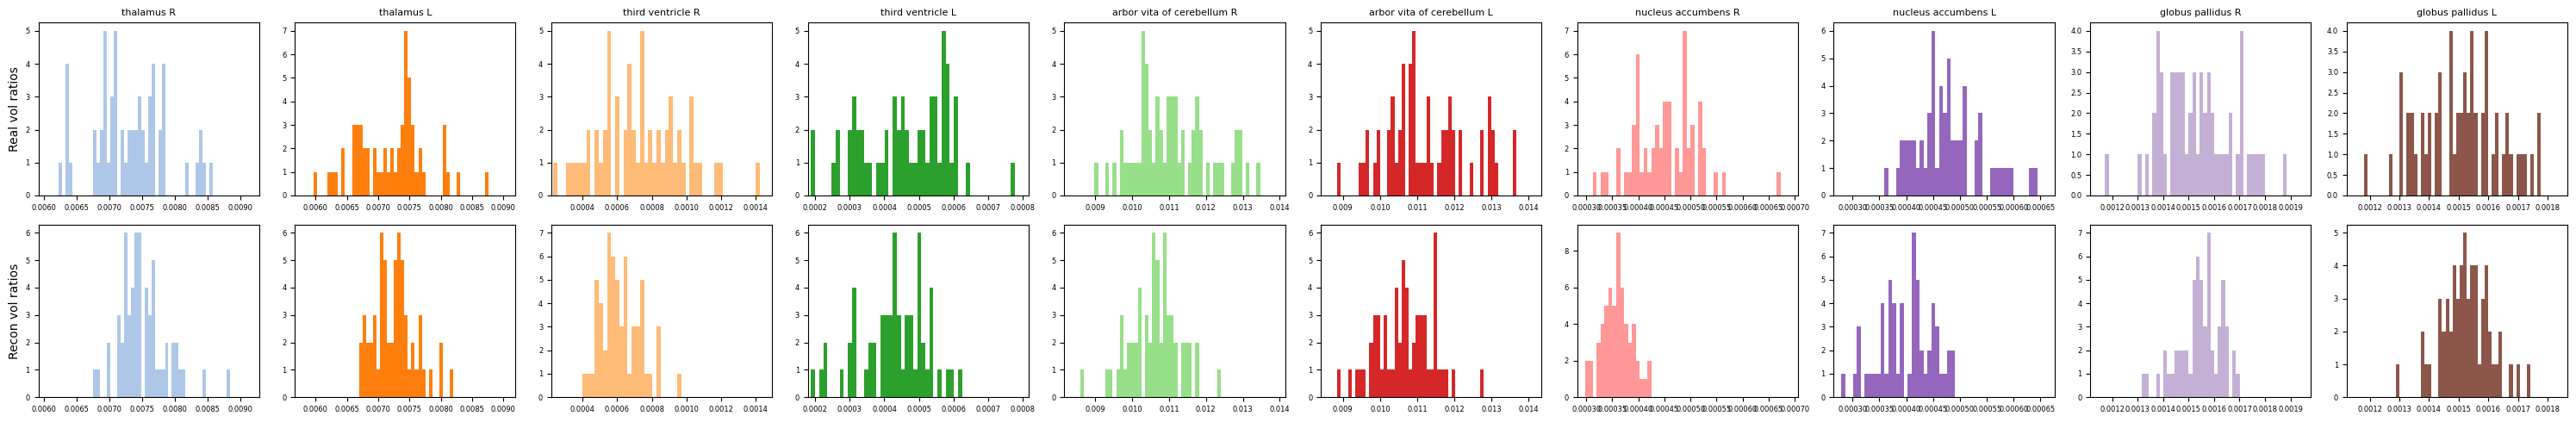

In [ ]:
real_imgs_path = "./datasets/3d_anat_align/human_test/"
recon_imgs_path = "./VAE_train/3d_anat/arc_human_train_7/recon_images_best/"

# compare downsampled
# real_imgs_path = "../../MDSC689.03-Final-Project/spring term/data/reg_human/mri_to_atlas/reg_anat_proc/"
# recon_imgs_path = "../../MDSC689.03-Final-Project/spring term/data/reg_human/mri_to_atlas/reg_anat_proc_64/"

recon_vol_ratios = compute_common_vol_ratios(recon_imgs_path)
real_vol_ratios = compute_common_vol_ratios(real_imgs_path)

img_idx=24
plot_vol_ratios(real_vol_ratios, recon_vol_ratios, struct_names, False, img_idx)


56
24


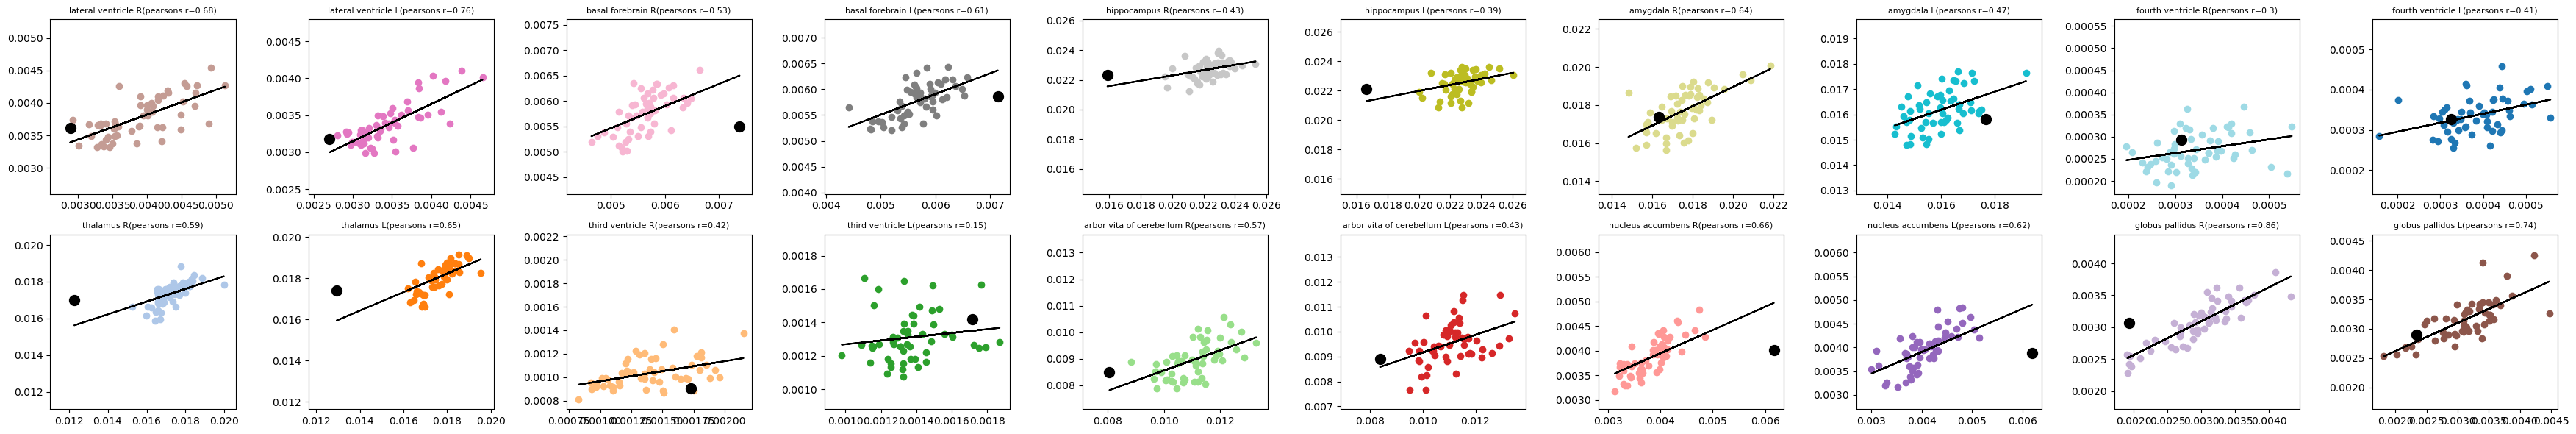

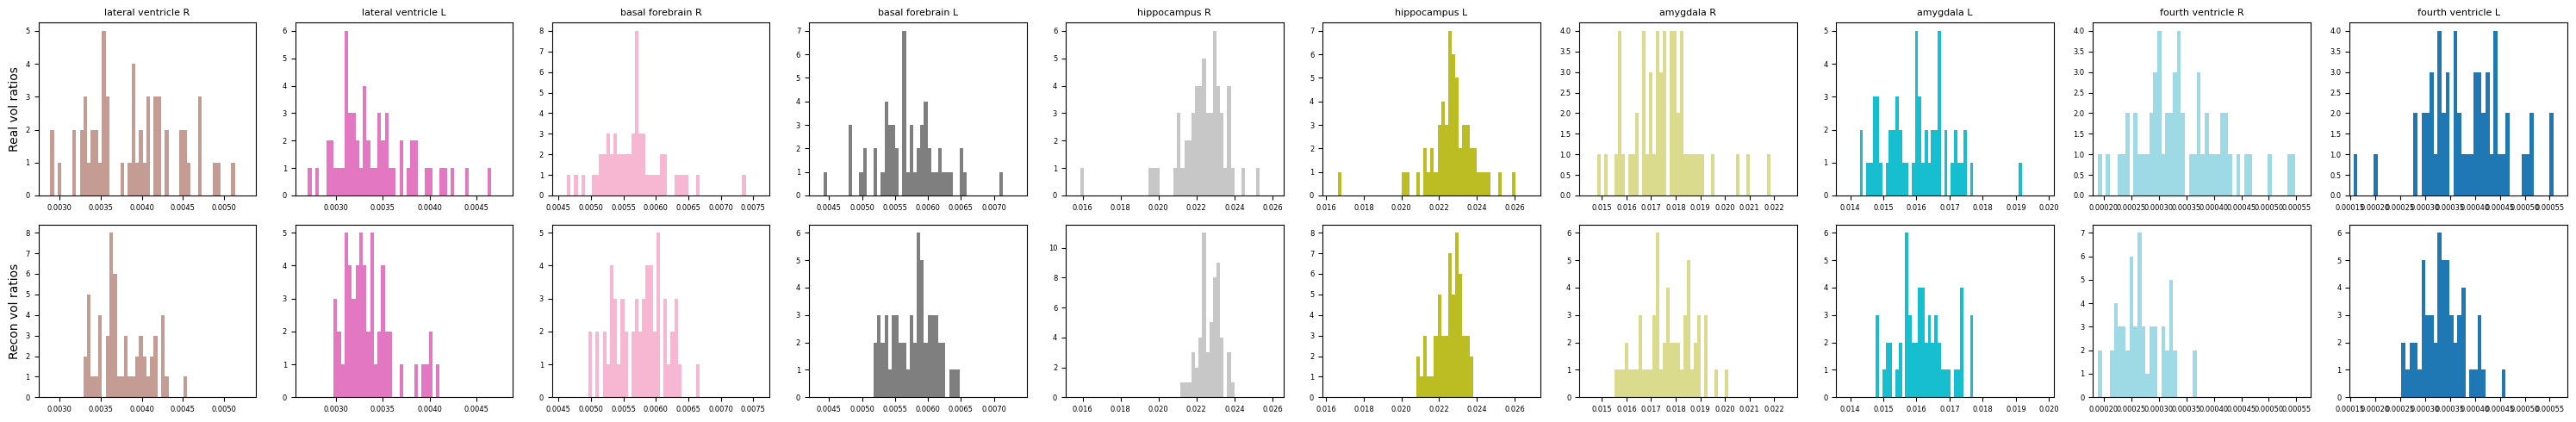

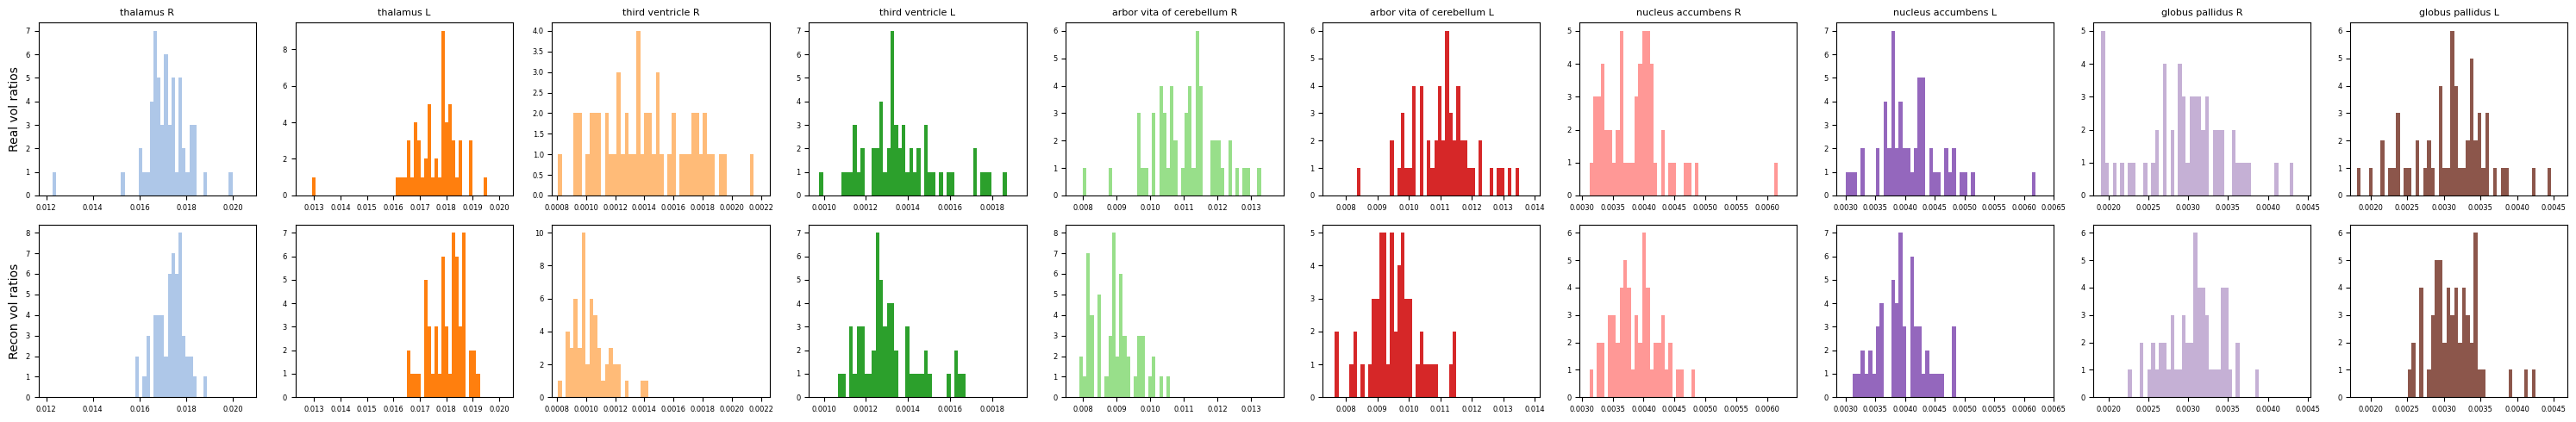

In [31]:
img_idx = 24
print(len(real_vol_ratios[:, 11]))
print(np.argmin(real_vol_ratios[:, 11]))
plot_vol_ratios(real_vol_ratios, recon_vol_ratios, struct_names, True, img_idx)

## Extending to 2D

In [6]:
def compute_common_vol_ratios_by_slice(folder_path):
    folder_list = os.listdir(folder_path)
    folder_list.sort()

    vol_ratios = []
    for file_name in folder_list:
        img = sitk.ReadImage(folder_path + file_name)
        img_arr = sitk.GetArrayFromImage(img)
        vol_ratios_slice = []

        for i in range(img_arr.shape[0]):
            vol_ratios_slice.append(get_vol_ratio(img_arr[i]))

        vol_ratios.append(vol_ratios_slice)

    return vol_ratios


human_real_imgs_path = "./datasets/anat/human_test/"
ratios = compute_common_vol_ratios_by_slice(human_real_imgs_path)
ratios = np.array(ratios)
human_large_r_thal_idx = np.argmax(ratios[:, :, 10], axis=1) # over slice?

mouse_real_imgs_path = "./datasets/anat/mouse_test/"
ratios = compute_common_vol_ratios_by_slice(mouse_real_imgs_path)
ratios = np.array(ratios)
mouse_large_r_thal_idx = np.argmax(ratios[:, :, 10], axis=1) # over slice?



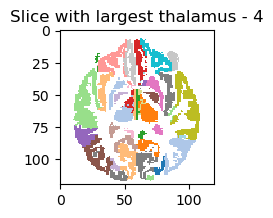

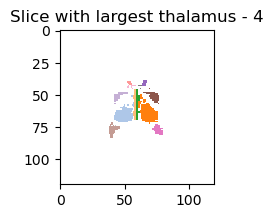

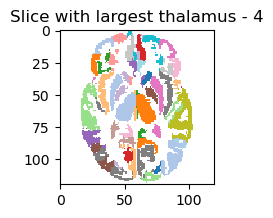

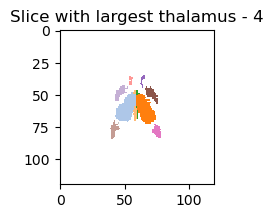

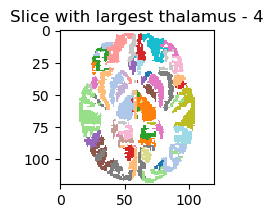

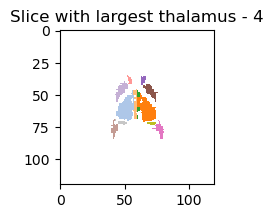

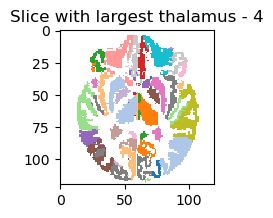

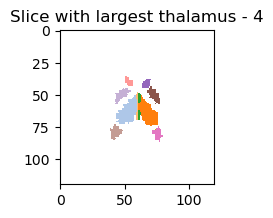

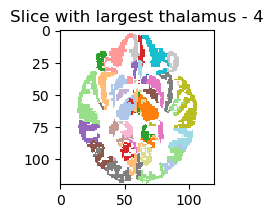

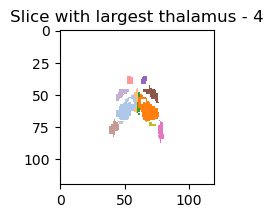

In [7]:
real_imgs_files = os.listdir(human_real_imgs_path)
real_imgs_files.sort()

for i, slice_idx in enumerate(human_large_r_thal_idx[:5]):
    real_img = sitk.GetArrayFromImage(sitk.ReadImage(human_real_imgs_path + real_imgs_files[i]))
    plot_seg(real_img, slice_idx - 4 + 2, size, "Slice with largest thalamus - 4")

    real_common = real_img
    real_common[real_img < 251] = 0
    plot_seg(real_common, slice_idx - 4 + 2, size, "Slice with largest thalamus - 4")

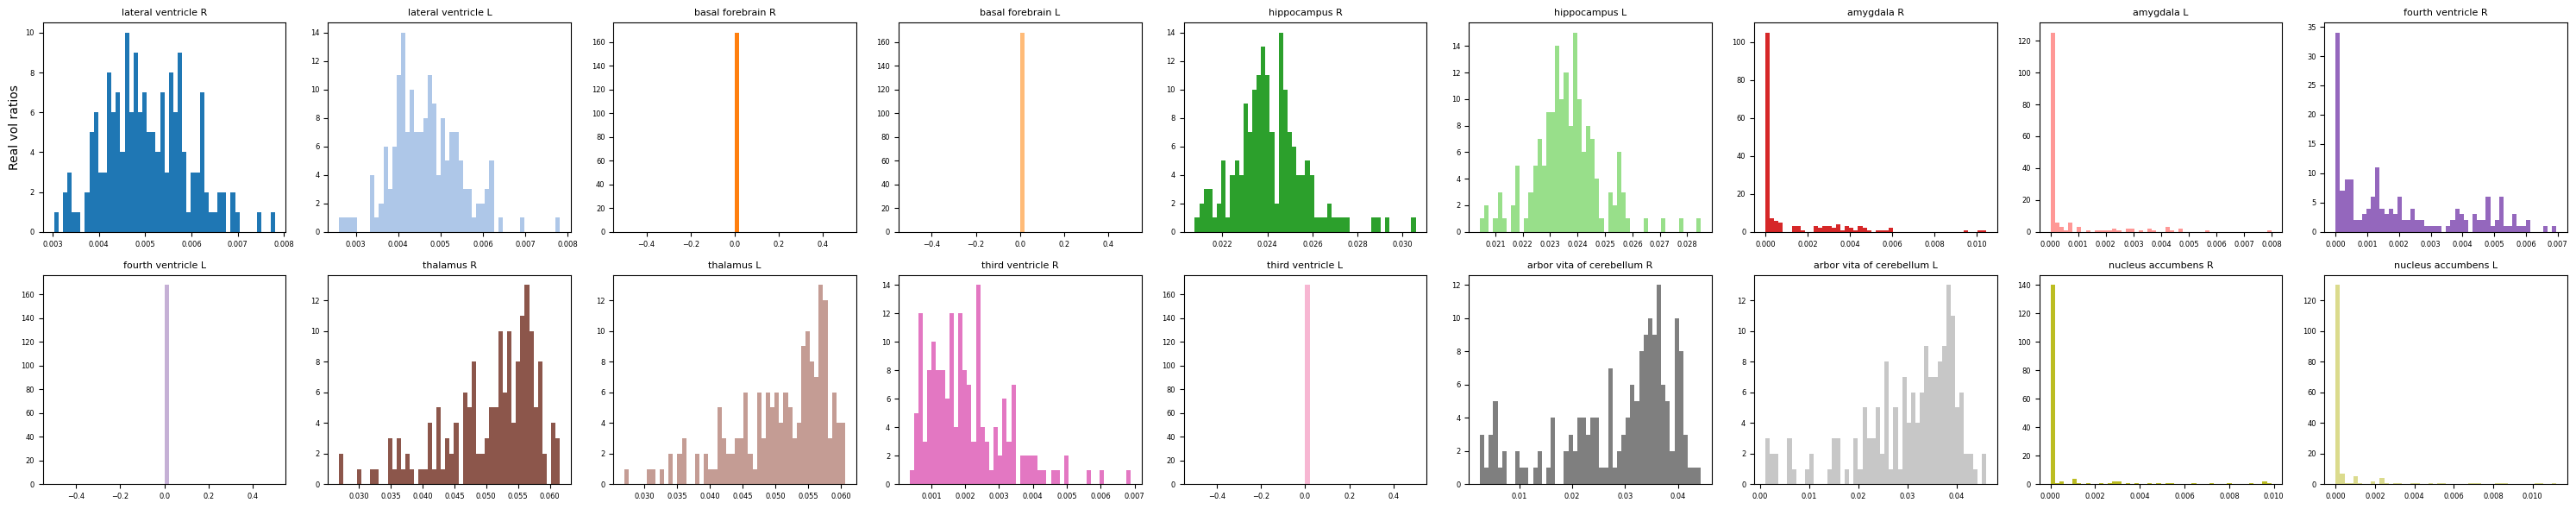

In [8]:
def plot_vol_ratios(real_vol_ratios, stuct_names):
    bins = 50

    fig, axs = plt.subplots(2, 9, figsize=(30, 6))
    
    for i in range(9):
        color = base_colors[i % len(base_colors)]
    
        # Real
        axs[0, i].hist(real_vol_ratios[:, i], bins, color=color)
        axs[0, i].set_title(struct_names[i], fontsize=8)
        axs[0, i].tick_params(labelsize=6)

        color = base_colors[(i + 9) % len(base_colors)]
    
        axs[1, i].hist(real_vol_ratios[:, i+9], bins, color=color)
        axs[1, i].set_title(struct_names[i+9], fontsize=8)
        axs[1, i].tick_params(labelsize=6)


    axs[0, 0].set_ylabel("Real vol ratios", fontsize=10)

    fig.tight_layout()
    fig.show()


# ratios_2d = np.array([ratios[i, human_large_r_thal_idx[i], :] for i in range(len(ratios))])

# print(ratios.shape)
# print(ratios_2d.shape)

ratios_2d = compute_common_vol_ratios("./datasets/anat_2d/mouse_test/")

plot_vol_ratios(ratios_2d, struct_names)

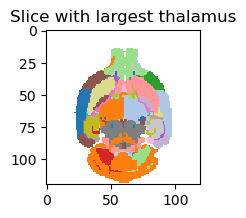

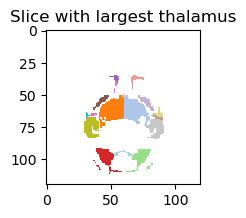

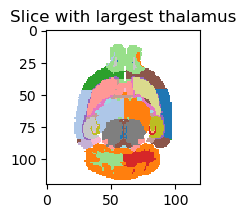

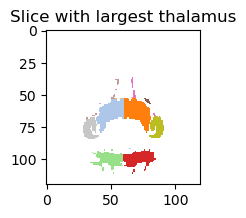

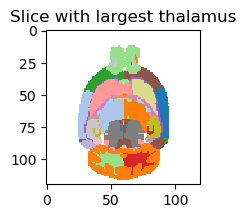

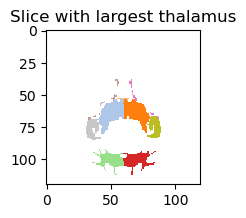

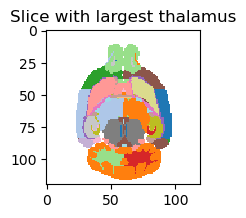

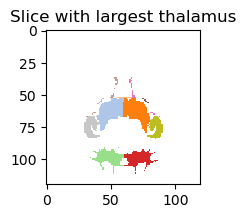

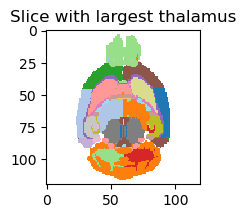

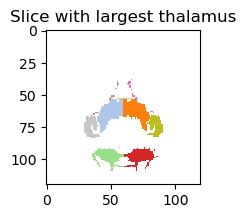

In [9]:
real_imgs_files = os.listdir(mouse_real_imgs_path)
real_imgs_files.sort()

for i, slice_idx in enumerate(mouse_large_r_thal_idx[:5]):
    real_img = sitk.GetArrayFromImage(sitk.ReadImage(mouse_real_imgs_path + real_imgs_files[i]))
    plot_seg(real_img, slice_idx - 2, size, "Slice with largest thalamus")

    real_common = real_img
    real_common[real_img < 251] = 0
    plot_seg(real_common, slice_idx - 2, size, "Slice with largest thalamus")


## Slice and save the anat segs

In [10]:
folder_path = "./datasets/anat/mouse_test/"
save_path = "./datasets/anat_2d/mouse_test/"
slice_offset = 0

vol_ratios = compute_common_vol_ratios_by_slice(folder_path)
vol_ratios = np.array(vol_ratios)
print(vol_ratios.shape)
print(np.array(os.listdir(folder_path)).shape)

os.makedirs(save_path, exist_ok=True)

# 10 for thalumus
large_r_thal_idx = np.argmax(vol_ratios[:, :, 10], axis=1) # over slice?

for i, file_name in enumerate(os.listdir(folder_path)):
    img_arr = sitk.GetArrayFromImage(sitk.ReadImage(folder_path + file_name))

    for slice_idx in range(large_r_thal_idx[i] - 1, large_r_thal_idx[i] + 1 + 1):
        sitk.WriteImage(sitk.GetImageFromArray(img_arr[slice_idx + slice_offset]), save_path + "s_" + str(slice_idx) + "_" + file_name)


    

(56, 128, 20)
(56,)
